## Purpose

This notebook is being created in response to the week 7 meeting and the protein expression results in PMN cells which give me some questions on parts of my data namly, are the PMN cells actually PMN cells (they are low in CD15 and CD16). Conversely they are high in the VIM protein which is not expected to be high in nuetrophils. The VIM gene is more commonly expressed in fibroblast, endothelial cells, some cancer cells, and marcophages. 


### Protein Data Load

In [1]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
# expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0)

#Load files on Lab computer
expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\expression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\metadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\umap.csv", index_col=0)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
# adata.obsm["spatial"] = metadata[['x_FOV_px', 'y_FOV_px']].values  # adjust if needed
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px = -metadata['y_FOV_px']).values # Note that the Y acis is inverted. This is done to standardize with RNA plots

C:\Users\ejohns\AppData\Local\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\ejohns\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\ejohns\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
C:\Users\ejohns\AppData\Local\anaconda3\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import annd

#### PMN Heatmap Functions

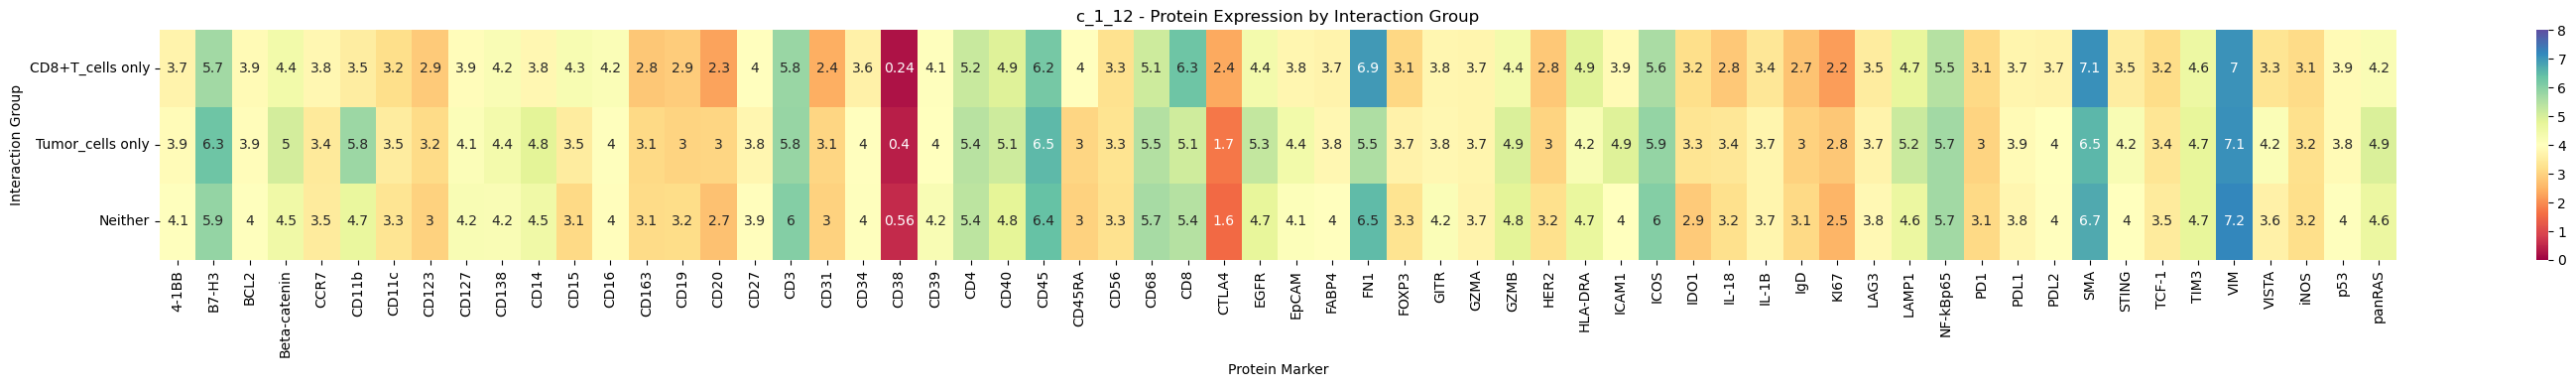

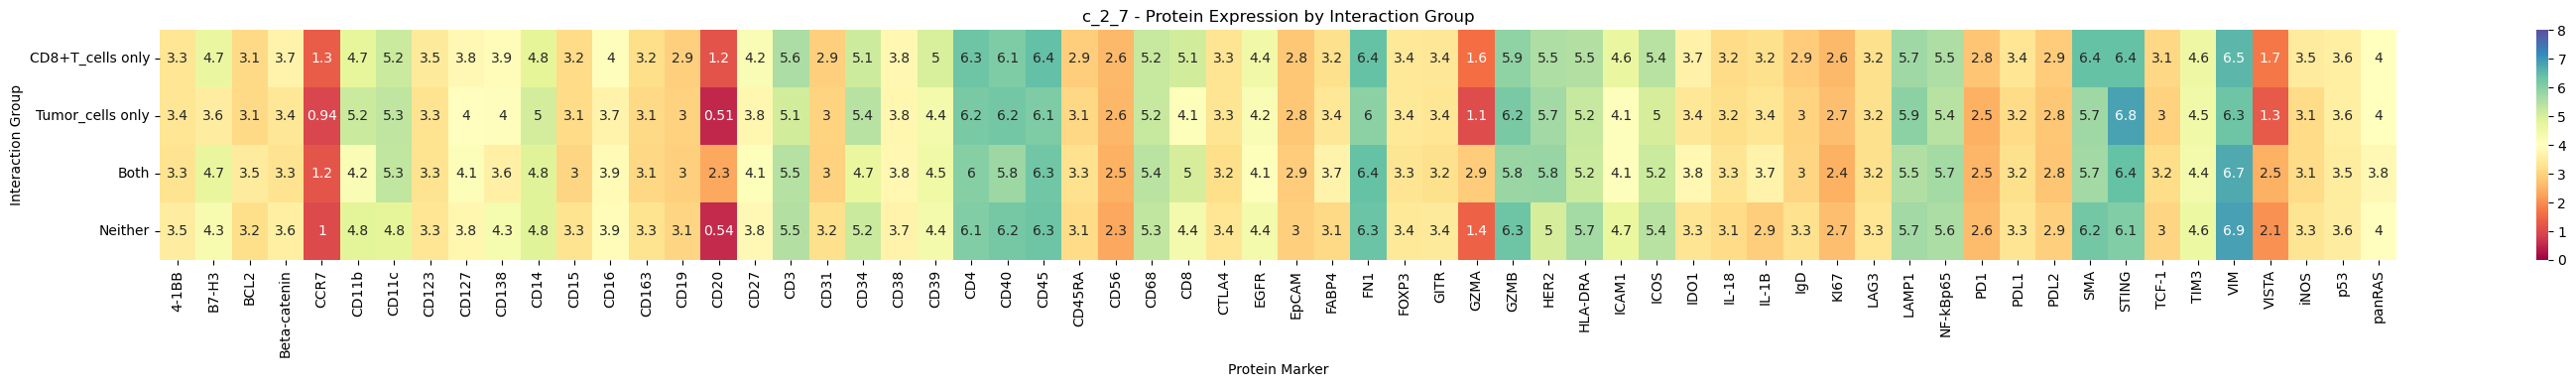

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import my_functions

def plot_grouped_protein_heatmap(adata, interaction_matrix, protein_layer=None, title="Protein Expression by Interaction Group"):
    """
    Plots a heatmap of average protein expression across interaction groups (CD8, Tumor, Both, Neither).

    Parameters
    ----------
    adata : AnnData
        Annotated data object containing protein expression data (in `.X` or a `.layers[]` slot).

    interaction_matrix : pandas.DataFrame
        Output of get_interaction_status()["Interaction Matrix"], must have 'Interaction_Status'.

    protein_layer : str or None, optional
        If provided, uses adata.layers[protein_layer] for protein expression.
        If None, uses adata.X.

    title : str
        Title of the heatmap plot.

    Returns
    -------
    None
        Displays the heatmap.
    """
    # Ensure index alignment between interaction_matrix and adata
    adata_subset = adata[interaction_matrix.index].copy()
    adata_subset.obs['Interaction_Status'] = interaction_matrix['Interaction_Status']

    # Get expression matrix
    if protein_layer is not None:
        expr = adata_subset.layers[protein_layer]
    else:
        expr = adata_subset.X

    # Convert to DataFrame
    expr_df = pd.DataFrame(expr.toarray() if hasattr(expr, 'toarray') else expr,
                           index=adata_subset.obs_names,
                           columns=adata_subset.var_names)

    # Add interaction labels
    expr_df['Interaction_Status'] = adata_subset.obs['Interaction_Status']

    # Group and average
    grouped_expr = expr_df.groupby('Interaction_Status').mean()

    # Reorder rows if desired
    desired_order = ['CD8+T_cells only', 'Tumor_cells only', 'Both', 'Neither']
    grouped_expr = grouped_expr.reindex([g for g in desired_order if g in grouped_expr.index])

    # Plot heatmap
    plt.figure(figsize=(30, 4))
    sns.heatmap(grouped_expr, cmap="Spectral", annot=True, vmin=0, vmax=8)
    plt.title(title)
    plt.ylabel('Interaction Group')
    plt.xlabel('Protein Marker')
    plt.tight_layout()
    plt.show()

# Sample 1:
sample_id="c_1_12"
distance_threshold=15
title=f"{sample_id} - Protein Expression by Interaction Group"
result = my_functions.get_interaction_status(adata, sample_id, distance_threshold)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap(adata, interaction_matrix,  title=title)

# Sample 2:
sample_id="c_2_7"
title=f"{sample_id} - Protein Expression by Interaction Group"
result = my_functions.get_interaction_status(adata, sample_id, distance_threshold=20)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap(adata, interaction_matrix, title=title)
    

#### Single Cell Type HeatMap

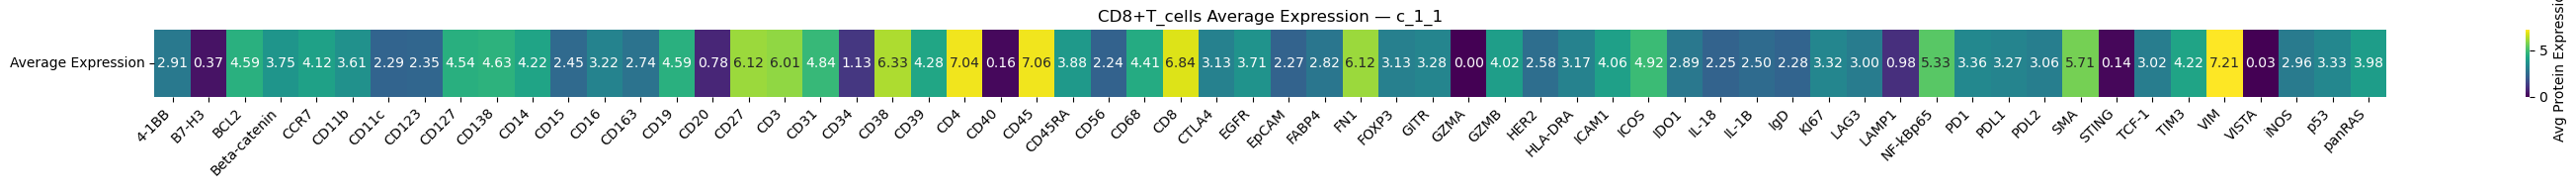

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_avgerage_expression(adata, sample_id, cell_type, protein_layer=None, fmt=".2f"):
    """
    Plots a heatmap of average protein expression for a specific cell type in a given sample.

    Parameters
    ----------
    adata : AnnData
        The AnnData object containing single-cell data.

    sample_id : str
        The sample ID (e.g., "c_1_1").

    cell_type : str
        The target cell type to filter (e.g., "CD8+T_cells").

    protein_layer : str or None
        Name of the layer to use for protein expression (e.g., "protein"). If None, uses adata.X.

    fmt : str
        Formatting for the heatmap annotations.

    Returns
    -------
    None
        Displays a heatmap of average protein expression.
    """
    # Get list of matching cell names
    cell_name_list = my_functions.matching_cell_list(adata, sample_id, cell_type)["Cell Names"]
    
    if len(cell_name_list) == 0:
        print(f"No cells found for {cell_type} in {sample_id}.")
        return

    # Subset adata
    adata_subset = adata[cell_name_list].copy()

    # Get expression matrix
    expr = adata_subset.layers[protein_layer] if protein_layer else adata_subset.X
    expr_df = pd.DataFrame(
        expr.toarray() if hasattr(expr, 'toarray') else expr,
        index=adata_subset.obs_names,
        columns=adata_subset.var_names
    )

    # Compute average expression
    avg_expr = expr_df.mean().to_frame(name="Average Expression").T

    # Plot heatmap
    plt.figure(figsize=(30, 2))
    sns.heatmap(avg_expr, cmap="viridis", annot=True, fmt=fmt, cbar_kws={"label": "Avg Protein Expression"})
    plt.title(f"{cell_type} Average Expression — {sample_id}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_avgerage_expression(adata,"c_1_1","CD8+T_cells")

#### All Cell Types Heatmap

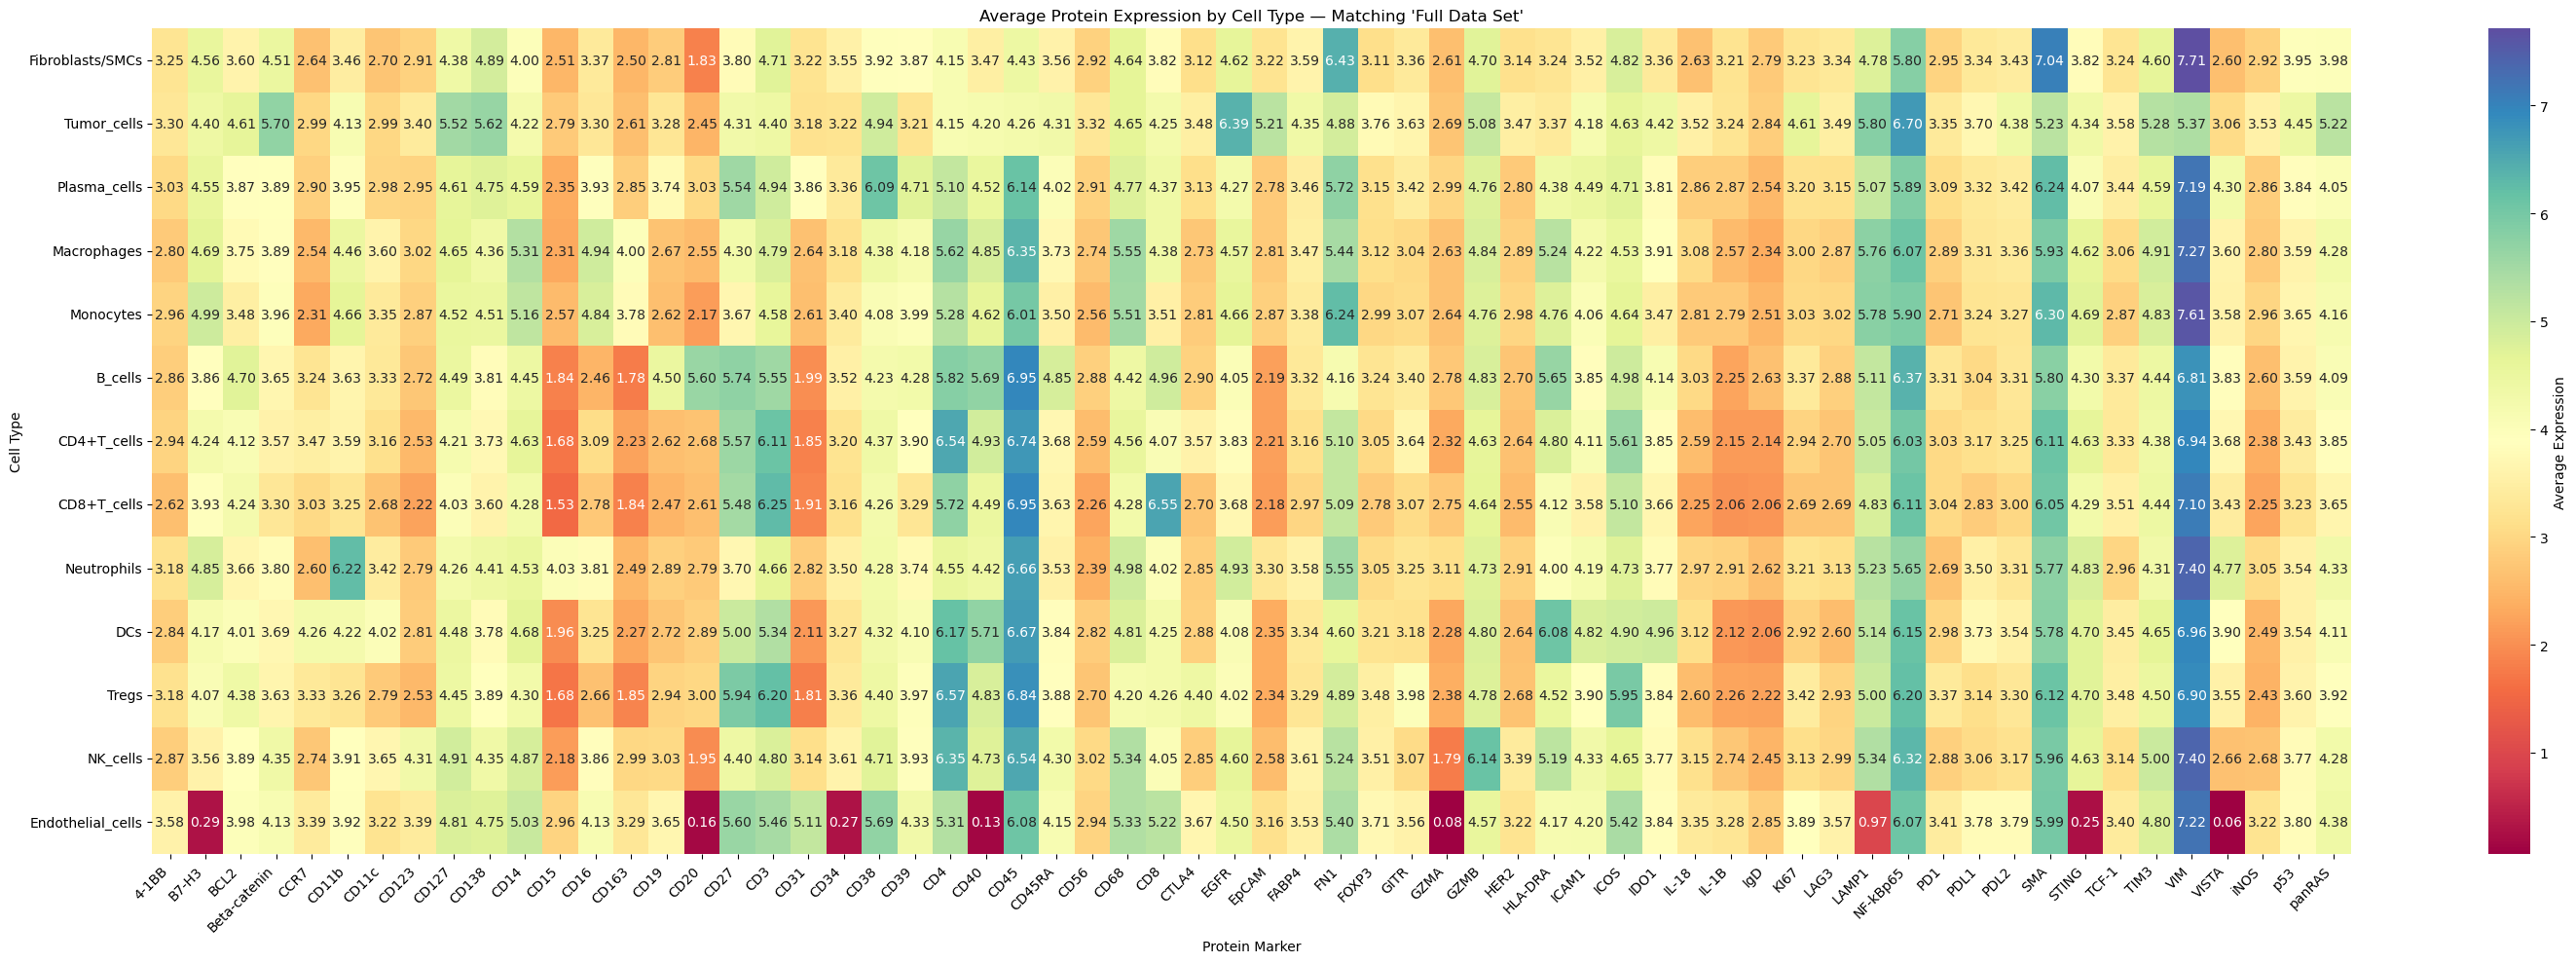

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_celltype_average_expression_all(adata, cell_ID_like, protein_layer=None, fmt=".2f", overall_map=False):
    """
    Plots a heatmap of average protein expression per cell type (from merged_annot_cluster)
    for cells whose cell_ID contains the given pattern.

    Parameters
    ----------
    adata : AnnData
        The annotated data matrix.
    cell_ID_like : str
        A substring to match within adata.obs['cell_ID'] (e.g., "c_1_1").
    protein_layer : str or None
        The layer to use for expression. If None, uses adata.X.
    fmt : str
        String format for heatmap annotations.
    overall map: 
    Returns
    -------
    None
        Displays a heatmap of average expression per cell type.
    """
    # Subset based on cell_ID match
    if overall_map!=True:
        subset = adata[adata.obs.cell_ID.str.contains(cell_ID_like)].copy()
        header_title=cell_ID_like
    else:
        subset = adata
        header_title="Full Data Set"

    if subset.n_obs == 0:
        print(f"No cells found matching pattern '{cell_ID_like}'.")
        return

    # Get unique cell types from merged_annot_cluster
    cell_types = subset.obs["merged_annot_cluster"].unique()

    avg_expr_list = []
    valid_cell_types = []

    for cell_type in cell_types:
        cell_mask = subset.obs["merged_annot_cluster"] == cell_type
        cell_group = subset[cell_mask]

        if cell_group.n_obs == 0:
            continue

        expr = cell_group.layers[protein_layer] if protein_layer else cell_group.X
        expr_df = pd.DataFrame(
            expr.toarray() if hasattr(expr, "toarray") else expr,
            index=cell_group.obs_names,
            columns=cell_group.var_names
        )

        avg_expr_list.append(expr_df.mean())
        valid_cell_types.append(cell_type)

    if not avg_expr_list:
        print(f"No valid cell types found in subset matching '{cell_ID_like}'.")
        return

    avg_matrix = pd.DataFrame(avg_expr_list, index=valid_cell_types)
    

    # Plot heatmap
    plt.figure(figsize=(30, 10))
    sns.heatmap(avg_matrix, cmap="Spectral", annot=True, fmt=fmt, cbar_kws={"label": "Average Expression"})
    plt.title(f"Average Protein Expression by Cell Type — Matching '{header_title}'")
    plt.xlabel("Protein Marker")
    plt.ylabel("Cell Type")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
plot_celltype_average_expression_all(adata, "c_1_1",overall_map=True)

### Summary acrross Samples

In [16]:
import my_functions

def get_interaction_status(adata,sample_id, distance_threshold, cell_type_1="CD8+T_cells",cell_type_2="Tumor_cells"):
    """
    Classifies PMN cell interactions with two specified cell types (e.g., CD8+ T cells and Tumor cells)
    based on spatial proximity from a distance matrix.
    Parameters
    ----------
    adata : AnnData
        The annotated data object containing spatial transcriptomics or single-cell data.
    sample_id : str
        Identifier for the sample to analyze within `adata`.
    distance_threshold : float
        Distance in microns to define interaction (e.g., 20 means a cell is interacting if it's ≤ 20 microns away).
    cell_type_1 : str, optional
        First target cell type to assess interaction with (default is "CD8+T_cells").
    cell_type_2 : str, optional
        Second target cell type to assess interaction with (default is "Tumor_cells").
    Returns
    -------
    dict
        A dictionary with one key:
        - "Interaction Matrix": pandas.DataFrame with:
            * Boolean columns: 
              - '{cell_type_1} Interacting'
              - '{cell_type_2} Interacting'
            * Categorical column:
              - 'Interaction_Status' (values: 'Both', '{cell_type_1} only', '{cell_type_2} only', 'Neither')
    """
    import pandas as pd
    
    # Load distance matrices
    results_CD8 = nearest_cells_of_particular_type(adata,sample_id, cell_type_1)["Distance Matrix"]
    results_Tumor = nearest_cells_of_particular_type(adata,sample_id, cell_type_2)["Distance Matrix"]
    
    # Set interaction threshold (in microns)
    threshold = distance_threshold
    
    # Initialize result matrix
    output = pd.DataFrame(index=results_CD8.index)
    output[f'{cell_type_1} Interacting'] = results_CD8['Minimum Distance'] <= threshold
    output[f'{cell_type_2} Interacting'] = results_Tumor['Minimum Distance'] <= threshold
    
    # Compute interaction status
    def classify(row):
        if row[f'{cell_type_1} Interacting'] and row[f'{cell_type_2} Interacting']:
            return 'Both'
        elif row[f'{cell_type_1} Interacting']:
            return f'{cell_type_1} only'
        elif row[f'{cell_type_2} Interacting']:
            return f'{cell_type_2} only'
        else:
            return 'Neither'
    
    output['Interaction_Status'] = output.apply(classify, axis=1)

    return{
        "Interaction Matrix":output
    }

# Sample 1:
sample_id="c_1_12"
distance_threshold=15
title=f"{sample_id} - Protein Expression by Interaction Group"
result = get_interaction_status(adata, sample_id, distance_threshold)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap(adata, interaction_matrix,  title=title)

# Sample 2:
sample_id="c_2_7"
title=f"{sample_id} - Protein Expression by Interaction Group"
result = get_interaction_status(adata, sample_id, distance_threshold=20)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap(adata, interaction_matrix, title=title)

NameError: name 'nearest_cells_of_particular_type' is not defined

### Making Pie Charts

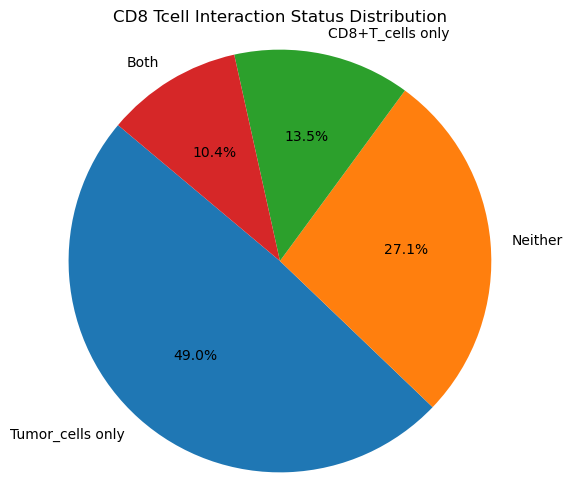

In [18]:
import my_functions

results2=my_functions.get_interaction_status_v2(adata,"c_1_22", 15, "Neutrophil", cell_type_1="CD8+T_cells",cell_type_2="Tumor_cells")
plot_interaction_status_pie_v2(results2["Interaction Matrix"],title = "CD8 Tcell Interaction Status Distribution")